1. runner 동작 방식 이해 
처음 my-first-agent 수동 방식과 동일한 방식 

사용할 도구와 args 
도구 호출로 결과 get 
결과를 가지고 message 생성 

In [7]:
from agents import Agent, Runner, function_tool, ItemHelpers

@function_tool 
def get_weather(city: str):
    """
        Get weather by city
    """
    print(city)
    return "33 degrees"; 

agent = Agent(
    name="Assistant Agent",
    instructions= "You are a helpful assistant. Use tools when needed to answer questions.",
    tools=[get_weather]
)

stream = Runner.run_streamed(agent, "Hi how are you? What is the weather in tokyo?")

async for event in stream.stream_events():
    if (event.type == "raw_response_event"):
        continue
    elif (event.type == "agent_updated_stream_event"):
        print("Agent updated to " + event.new_agent.name)
    elif (event.type == "run_item_stream_event"):
        if (event.item.type == "tool_call_item"):
            print(event.item.raw_item.to_dict())
        elif (event.item.type == "tool_call_output_item"):
            print(event.item.output)
        elif (event.item.type == "message_output_item"):
            print(ItemHelpers.text_message_output(event.item))
    print("="*20)

Agent updated to Assistant Agent
{'arguments': '{"city":"Tokyo"}', 'call_id': 'call_nGD9asP06zrUoSvNpNSMgwat', 'name': 'get_weather', 'type': 'function_call', 'id': 'fc_0d9e063249ff44bc006a34e298a428819b8a93efd2165a03bc', 'status': 'completed'}
Tokyo
33 degrees
I’m doing well, thanks! Tokyo is 33° right now.


2. stream 방식 

In [10]:
from agents import Agent, Runner, function_tool, ItemHelpers

@function_tool 
def get_weather(city: str):
    """
        Get weather by city
    """
    print(city)
    return "33 degrees"; 

agent = Agent(
    name="Assistant Agent",
    instructions= "You are a helpful assistant. Use tools when needed to answer questions.",
    tools=[get_weather]
)

stream = Runner.run_streamed(agent, "Hi how are you? What is the weather in tokyo?")

message = "" 
args = ""

async for event in stream.stream_events():
    if (event.type == "raw_response_event"):
        event_type = event.data.type
        if (event_type == "response.output_text.delta"):
            message += event.data.delta
            print(message)
        elif (event_type == "response.function_call_arguments.delta"):
            args += event.data.delta
            print(args)
        elif (event_type == "response.completed"):
            message = ""
            args = ""


{"
{"city
{"city":"
{"city":"Tokyo
{"city":"Tokyo"}
Tokyo
I
I’m
I’m good
I’m good,
I’m good, thanks
I’m good, thanks!
I’m good, thanks! Tokyo
I’m good, thanks! Tokyo is
I’m good, thanks! Tokyo is 
I’m good, thanks! Tokyo is 33
I’m good, thanks! Tokyo is 33 degrees
I’m good, thanks! Tokyo is 33 degrees right
I’m good, thanks! Tokyo is 33 degrees right now
I’m good, thanks! Tokyo is 33 degrees right now.


3. 자동 memory 

In [ ]:
from agents import Agent, Runner, function_tool, SQLiteSession

session = SQLiteSession("user_2", "ai-memory.db")

@function_tool 
def get_weather(city: str):
    """
        Get weather by city
    """
    return "33 degrees"; 

agent = Agent(
    name="Assistant Agent",
    instructions= "You are a helpful assistant. Use tools when needed to answer questions.",
    tools=[get_weather]
)

result = await Runner.run(
    agent, 
    "Hi how are you? my name is jihwi", 
    session= session)
print(result.final_output)


I don’t know yet — you haven’t told me your name in this chat.


In [13]:
result = await Runner.run(agent, "i live in seoul", session= session)
print(result.final_output)

Nice to meet you, jihwi. Seoul is a great city.


In [15]:
result = await Runner.run(agent, "what was my name again?", session= session)
print(result.final_output)

jihwi


In [16]:
result = await Runner.run(agent, "what is the weather where i live?", session= session)
print(result.final_output)

It’s 33 degrees in Seoul.


In [ ]:
4. handoff

In [ ]:
from agents import Agent, Runner, SQLiteSession

session = SQLiteSession("user_3", "ai-memory.db")

geography_agent = Agent(
    name="Geo_Expert_Agent",
    instructions="You are a expert in geography, you answer questions related to them.", 
    handoff_description="Use this to answer geography related questions.",
)

economic_agent = Agent(
    name="Economics_Expert_Agent",
    instructions="You are a expert in economics, you answer questions related to them.", 
    handoff_description="Use this to answer economic related questions.",
)

main_agent = Agent(
    name="Main_Agent",
    instructions= "You are a user facing agent. Transfer to the agent most capable of answering the user's question.",
    handoffs=[
        geography_agent,
        economic_agent
    ]
)

In [26]:
result = await Runner.run(
    main_agent, 
    "Why is the second biggest city in Korea?", 
    session= session)

print(result.last_agent.name)   
print(result.final_output)


Geo_Expert_Agent
The second-biggest city in Korea is **Busan**.

If you meant **“Why is Busan the second biggest city?”**, the main reasons are:

- **Major port city** on the southeast coast
- **Trade and shipping hub** for Korea
- **Historic growth** from commerce, industry, and refugees during the Korean War
- **Large metropolitan area** with dense population

If you want, I can also explain **why Seoul is #1 and Busan is #2**.


In [24]:
await session.clear_session()

5. draw_graph & structure output 

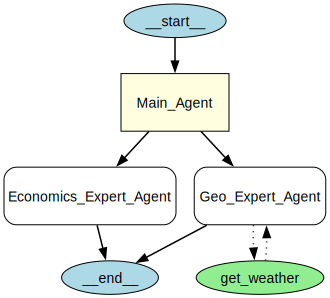

In [31]:
from agents import Agent, Runner, SQLiteSession, function_tool
from agents.extensions.visualization import draw_graph
from pydantic import BaseModel

class Answer(BaseModel):
    answer: str
    background_explanation: str 


@function_tool 
def get_weather():
    return "30"

session = SQLiteSession("user_3", "ai-memory.db")

geography_agent = Agent(
    name="Geo_Expert_Agent",
    instructions="You are a expert in geography, you answer questions related to them.", 
    handoff_description="Use this to answer geography related questions.",
    tools=[get_weather],
    output_type=Answer
)

economic_agent = Agent(
    name="Economics_Expert_Agent",
    instructions="You are a expert in economics, you answer questions related to them.", 
    handoff_description="Use this to answer economic related questions.",
)

main_agent = Agent(
    name="Main_Agent",
    instructions= "You are a user facing agent. Transfer to the agent most capable of answering the user's question.",
    handoffs=[
        geography_agent,
        economic_agent
    ]
)

draw_graph(main_agent)

In [38]:
result = await Runner.run(
    main_agent, 
    "몽골의 지리적 기후는 어떤가요?", 
    session= session)

print(result.last_agent.name)   
print(result.final_output)


Geo_Expert_Agent
answer='몽골은 전형적인 대륙성 고원 기후입니다. \n- 겨울: 매우 춥고 길다\n- 여름: 짧고 비교적 따뜻하다\n- 강수량: 적다(건조함)\n- 특징: 일교차·연교차가 크고, 사막·초원·산지 지형이 함께 나타납니다.\n\n한마디로, 몽골은 **춥고 건조하며 기온 변화가 큰 내륙 국가**입니다.' background_explanation='몽골은 해양의 영향을 거의 받지 않는 내륙에 위치해 있어 대륙성 기후가 강하게 나타납니다. 북쪽의 시베리아 고기압 영향으로 겨울이 매우 춥고, 여름은 짧지만 상대적으로 따뜻합니다. 또한 강수량이 많지 않아 초원과 사막 지형이 넓게 분포합니다.'


6. trace 
자동으로 모든 run마다 트래이스가 잡힘. openai platform log 대시보드에서 확인가능. 
그런데, 유저세션마다 모든 run을 그룹화 해서 보고 싶다면 

In [39]:
from agents import Agent, Runner, SQLiteSession, function_tool, trace
from agents.extensions.visualization import draw_graph
from pydantic import BaseModel

class Answer(BaseModel):
    answer: str
    background_explanation: str 


@function_tool 
def get_weather():
    return "30"

session = SQLiteSession("user_11111", "ai-memory.db")

geography_agent = Agent(
    name="Geo_Expert_Agent",
    instructions="You are a expert in geography, you answer questions related to them.", 
    handoff_description="Use this to answer geography related questions.",
    tools=[get_weather],
    output_type=Answer
)

economic_agent = Agent(
    name="Economics_Expert_Agent",
    instructions="You are a expert in economics, you answer questions related to them.", 
    handoff_description="Use this to answer economic related questions.",
)

main_agent = Agent(
    name="Main_Agent",
    instructions= "You are a user facing agent. Transfer to the agent most capable of answering the user's question.",
    handoffs=[
        geography_agent,
        economic_agent
    ]
)

In [40]:
with trace("user_11111"): 
    result = await Runner.run(
    main_agent, 
    "몽골의 지리적 기후는 어떤가요?", 
    session= session)

    result = await Runner.run(
    main_agent, 
    "서울의 지리적 기후는 어떤가요?", 
    session= session)

    result = await Runner.run(
    main_agent, 
    "미국의 지리적 기후는 어떤가요?", 
    session= session)